# SciPyWrapper-Style Distribution Wrapping Demo

Original QMCPy demo: [`QMCPy/demos/scipywrapper_dependence_custom/scipywrapper_demo.ipynb`](../../../QMCPy/demos/scipywrapper_dependence_custom/scipywrapper_demo.ipynb)

`QMC.jl` uses `DistributionsWrapper` as the direct analogue of QMCPy's `SciPyWrapper`. The shared core of this translation keeps the mixed-marginal dependence example with Julia-native wrappers, and then adds two lightweight custom true measures from `QMC.jl` as explicit Julia extensions.

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/QMCSoftware/QMC.jl/blob/develop/demos/scipywrapper_dependence_custom/scipywrapper_demo.ipynb)

Parity note: this Julia notebook keeps the same wrapped-distribution dependence example but replaces the Python SciPy wrapper stack with Julia-native distribution wrappers. The added `QMC.jl` custom true measures are labeled as Julia extensions rather than implied to be shared QMCPy content.


In [1]:
using QMC
using Distributions
using Statistics
using Printf

const HAVE_PLOTS = Base.find_package("Plots") !== nothing
HAVE_PLOTS && @eval using Plots
if HAVE_PLOTS
    Plots.default(
        titlefont=Plots.font(9),
        plot_titlefont=Plots.font(11),
        left_margin=4Plots.mm,
        right_margin=8Plots.mm,
        top_margin=8Plots.mm,
        bottom_margin=5Plots.mm,
    )
end


## Mixed Marginals with `DistributionsWrapper`

Wrap a discrete distribution with standard `Distributions.jl` marginals. The transformed samples should match the requested one-dimensional laws while preserving the low-discrepancy structure of the underlying point set.


In [2]:
dd = Lattice(3; seed=7)
tm = DistributionsWrapper(dd; marginals=[Normal(), Exponential(2.0), Beta(2, 5)])
x = transform(tm, gen_samples(dd, 4096))

summary_rows = [
    (name="Normal(0,1)", empirical_mean=mean(x[:, 1]), theoretical_mean=mean(Normal()), empirical_std=std(x[:, 1])),
    (name="Exponential(2)", empirical_mean=mean(x[:, 2]), theoretical_mean=mean(Exponential(2.0)), empirical_std=std(x[:, 2])),
    (name="Beta(2,5)", empirical_mean=mean(x[:, 3]), theoretical_mean=mean(Beta(2, 5)), empirical_std=std(x[:, 3])),
]
foreach(println, summary_rows)

@assert abs(summary_rows[1].empirical_mean - summary_rows[1].theoretical_mean) < 0.05
@assert abs(summary_rows[2].empirical_mean - summary_rows[2].theoretical_mean) < 0.05
@assert abs(summary_rows[3].empirical_mean - summary_rows[3].theoretical_mean) < 0.02


(name

 = "Normal(0,1)", empirical_mean = 0.0010604139539520888, theoretical_mean = 0.0, empirical_std = 1.0006474193648778)
(name = "Exponential(2)", empirical_mean = 2.0000703052425433, theoretical_mean = 2.0, empirical_std = 1.9996275204186211)
(name = "Beta(2,5)", empirical_mean = 0.28564712859909086, theoretical_mean = 0.2857142857142857, empirical_std = 0.1596651172533297)


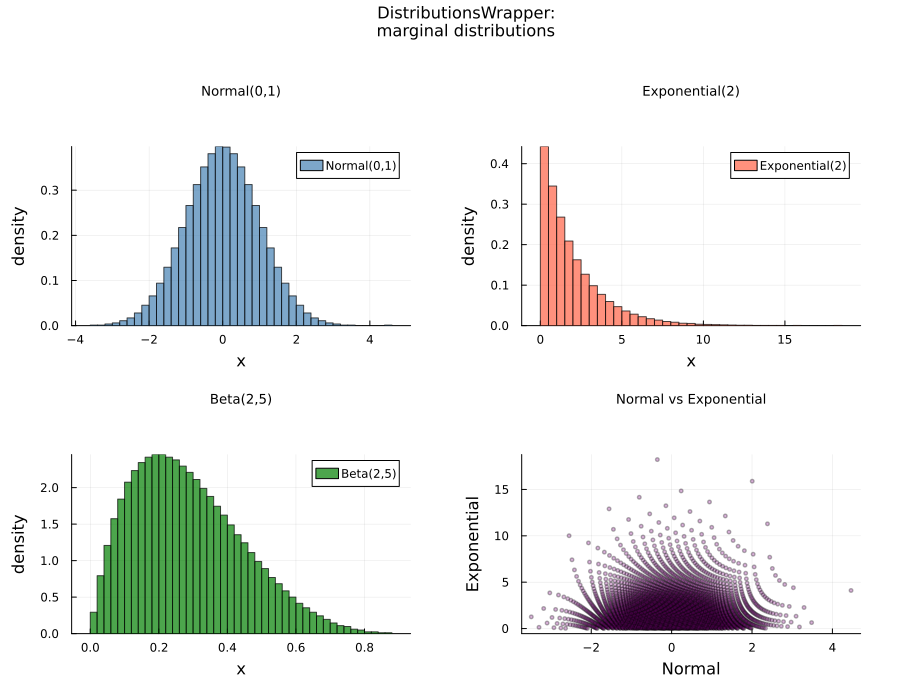

In [3]:
if HAVE_PLOTS
    marginal_names = ["Normal(0,1)", "Exponential(2)", "Beta(2,5)"]
    colors_m = [:steelblue, :tomato, :green]
    hist_plts = []
    for (i, (name, col)) in enumerate(zip(marginal_names, colors_m))
        hist_p = histogram(x[:, i]; bins=50, normalize=:pdf,
            alpha=0.7, color=col, label=name,
            xlabel="x", ylabel="density",
            title=name)
        push!(hist_plts, hist_p)
    end
    # Pairwise scatter: dim 1 vs dim 2
    p_scatter = scatter(x[:, 1], x[:, 2];
        markersize=2, alpha=0.3, color=:purple, label=nothing,
        xlabel="Normal", ylabel="Exponential",
        title="Normal vs Exponential")
    push!(hist_plts, p_scatter)
    display(plot(hist_plts...; layout=(2, 2), size=(900, 700),
        plot_titlevspan=0.12, plot_title="DistributionsWrapper:\nmarginal distributions",
        top_margin=10Plots.mm, bottom_margin=5Plots.mm))
end


## Julia Extensions: Custom True Measures Available in `QMC.jl`

The Python notebook also mixes in custom true measures. Two lightweight Julia examples are `ZeroInflatedExpUniform` and `UniformTriangle`.


In [4]:
zi_tm = ZeroInflatedExpUniform(Lattice(2; seed=7); p_zero=0.3, rate=2.0)
zi_x = transform(zi_tm, gen_samples(zi_tm.dd, 4096))
zero_fraction = mean(vec(zi_x) .== 0.0)
@printf("ZeroInflatedExpUniform: zero fraction = %.4f, sample mean = %.4f
", zero_fraction, mean(zi_x))

tri_tm = UniformTriangle(Lattice(2; seed=7))
tri_x = transform(tri_tm, gen_samples(tri_tm.dd, 4096))
@printf("UniformTriangle: mean(x₁) = %.4f, mean(x₂) = %.4f, constraint satisfied = %s
", mean(tri_x[:, 1]), mean(tri_x[:, 2]), all(tri_x[:, 1] .>= tri_x[:, 2]))

@assert abs(zero_fraction - 0.3) < 0.02
@assert all(tri_x[:, 1] .>= tri_x[:, 2])


ZeroInflatedExpUniform: zero fraction = 0.3000, sample mean = 0.3497
UniformTriangle: mean(x₁) = 0.6668, mean(x₂) = 0.3334, constraint satisfied = true


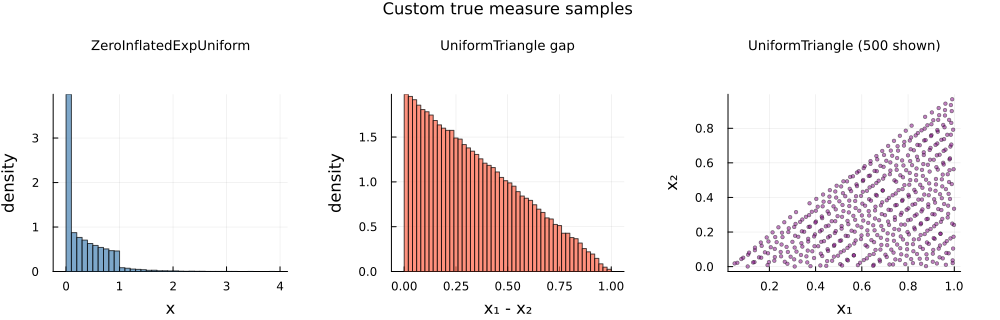

In [5]:
if HAVE_PLOTS
    p1 = histogram(zi_x[:, 1]; bins=50, normalize=:pdf,
        alpha=0.7, color=:steelblue, label=nothing,
        xlabel="x", ylabel="density",
        title="ZeroInflatedExpUniform")
    p2 = histogram(tri_x[:, 1] .- tri_x[:, 2]; bins=50, normalize=:pdf,
        alpha=0.7, color=:tomato, label=nothing,
        xlabel="x₁ - x₂", ylabel="density",
        title="UniformTriangle gap")
    p3 = scatter(tri_x[1:500, 1], tri_x[1:500, 2];
        markersize=2, alpha=0.5, color=:purple, label=nothing,
        xlabel="x₁", ylabel="x₂",
        title="UniformTriangle (500 shown)")
    display(plot(p1, p2, p3; layout=(1, 3), size=(1000, 320),
        plot_titlevspan=0.12, plot_title="Custom true measure samples",
        top_margin=10Plots.mm, bottom_margin=5Plots.mm))
end
